Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Exercise03

## Problem

In the last exercise, you used tabular analyses to examine how eviction impacts tenants in Montgomery and Prince George's Counties. In this exercise, you will use more precise, address-level data to analyze evictions across the entire state through a spatial lens.

**You get to write your own research question, but with a few constraints:**
- It should be addressable with the provided eviction data
- It should require that you relate the eviction data to at least one other dataset, which you provide
- It should involve at least one form of spatial analysis (e.g., proximity, overlay, or measurement of another spatial relationship)

**Please write a short abstract (200-300 words) at the top of your exercise notebook that concisely summarizes your research question, how you addressed it, and the results of your analysis. Then provide reproducible code in cells below.**

### Bonus

Only a portion of the eviction records I'm providing for this exercise have addresses that can be geocoded (converting address strings to geographic coordinates) with a high degree of accuracy, or even at all. How could you assess bias in which records are accurately geocoded? (Hint: This will require you to define accuracy.) Can you write a Python script that evaluates whether higher- and lower-accuracy geocodes are randomly distributed across eviction records, or whether certain types of evictions are more or less likely to be geocoded well? **Please report your approach and findings in a separate paragraph and provide supporting code.**

## Data

[Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT)

I'm providing you with eviction warrant data for the whole state of Maryland from 2022 through December 2024. These are from the same District Court of Maryland and Department of Housing and Community Development (DHCD) [source](https://app.powerbigov.us/view?r=eyJrIjoiYWI1Yzg0YjYtNDFkZS00MDUyLThlMDctYmE1ZjY5MGI0MWJhIiwidCI6IjdkM2I4ZDAwLWY5YmUtNDZlNy05NDYwLTRlZjJkOGY3MzE0OSJ9&pageName=ReportSection) as the data from Exercise 2, but also include street addresses. While these data are technically public, it is best practice not to store address-level data on a public GitHub repository. It is also a best practice not to commit large raw data files to Git. For both these reasons, I have shared this dataset in a [Google Drive](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT) folder to which your UMD account has been invited. You should download `md_eviction_warrants_through_2024.csv` store it in the exercise03 directory on your computer before starting to code. 

There is a `.gitignore` file in the exercise03 directory that prevents any `.csv` file from being tracked by Git. As long as you don't modify this `.gitignore`, the raw data file won't get committed, pushed to your remote fork, or included in a pull request back to the course repo.

## File Management and Submitting
To submit, please:
1. Make a new branch on your fork for this exercise.
2. Make a notebook for your exercise with your first name as an underscored suffix (e.g., `exercise02_chester.ipynb`)
    - You can either copy this notebook to work off of or start with a fresh notebook. Your choice.
4. Make commits to that branch as you work on the exercise.
5. Don't commit the eviction warrant CSV or other raw data files to Git.
    - Instead, please add any other raw data files your analysis depends on the [Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT).
    - The current `.gitignore` will prevent CSV files from committing. Add additional file names/extensions as necessary.
6. Make a pull request from your branch. Ensure that the only files included in your pull request are those you intended for this exercise.

## Getting Started
To get started, here's some code I developed for geocoding the address in each eviction warrant into a geographic coordinate. You can include all or parts of this code in your own exercise, or just run this notebook to produce the `md_eviction_warrants_through_2024.geoparquet` file and import it into your own notebook to use the results.

### U.S. Census Geocoder
This geocoding process makes use of a [free geocoder provided by the US Census](https://geocoding.geo.census.gov/geocoder/). It's not the most accurate geocoder available, but it's free and fast.

### Breaking Code Into Modules
In this geocoding process, I'm demonstrating an approach to coding where you break code up into multiple modules and then import names between modules. This helps keep things tidy, allows you to easily reuse code that's generalizable between applications (e.g., the `utils.py` module here), and organize code used for more specific purposes (e.g., the `exercise03.py` and `census_geocode.py` modules).

This is exactly how packages work——modules are the basic building blocks. If you wrote an interconnected set of modules to address a certain problem space, you could publish it as a package and let others download it with conda or pip. That's how open-source software gets its start!

### Abstract
My research question is; do housing prices affect eviction rates? I want to see if housing prices being higher makes it so people are more likely to be evicted, or if the inverse is true. This could be expanded further by adding in some time analysis, but that would require a great deal more work, particularly in cleaning the data. I needed two bits of data for this analysis, the most current housing data, which was provided by Zillow, and a shapefile in order to provide something for the housing data to be put on. I decided to use zip codes for my polygons, which both Zillow and TIGER were able to work with. I had to clean the Zillow data down to only the most recent housing prices, take out some extraneous columns, and making housing prices easier to read. Both were then imported into Python and converted into GeoDataFrames. After merging, the dataframe was then plotted using the housing prices as the main data to create a choropleth map. When compared, which is admittedly a bit difficult due to the scales, we can see that the areas with the highest housing prices, like Bethesda in Montgomery County, do not have high rates of evictions. The highest concentration appears to be in the strip of housing prices on the edge of Prince George's County and further south. This may imply that housing prices could be a factor, but rather than high price being a determinate, it's middling prices and perhaps those with increasing value. Again, a time analysis could have made this analysis stronger. 

In [1]:
import pandas as pd
import geopandas as gpd
import utils
import exercise03
import census_geocode
import matplotlib as plt

%load_ext autoreload
%autoreload 2

In [ ]:
# Both files are imported and read before being converted into dataframes.
csvfile = r"C:\Users\zedsl\Documents\GitHub\ursp688y_sp2026\exercises\exercise03\Zillow Housing Prices by Zip Code.csv"
shpfile = r"C:\Users\zedsl\Documents\GitHub\ursp688y_sp2026\exercises\exercise03\tl_2025_us_zcta520.shp"
csvdf = gpd.read_file(csvfile)
shpdf = gpd.read_file(shpfile)


In [ ]:
# An empty GeoDataFrame is created and then is given columns for geometry and zipcodes. This shift from the shapefile
# makes future manipulation easier. Geometry is required for the GeoDataFrame for plotting. The zip codes are added 
# as an integer since it would be imported as a pandas.series otherwise.
gdb = gpd.GeoDataFrame()
gdb["Geometry"] = shpdf["geometry"]
gdb["Zipcode"] = shpdf["ZCTA5CE20"].astype("int")
print(gdb)

                                                Geometry  Zipcode
0      POLYGON ((-107.85404 37.08409, -107.85403 37.0...    81137
1      POLYGON ((-103.70667 38.68072, -103.70602 38.6...    80823
2      POLYGON ((-106.6865 38.57901, -106.68645 38.57...    81237
3      POLYGON ((-106.58611 39.09058, -106.58616 39.0...    81251
4      POLYGON ((-108.19918 37.82435, -108.19915 37.8...    81435
...                                                  ...      ...
33786  POLYGON ((-122.43224 45.3899, -122.43216 45.39...    97009
33787  POLYGON ((-123.62197 43.32378, -123.62195 43.3...    97486
33788  MULTIPOLYGON (((-122.52874 45.42754, -122.5278...    97015
33789  POLYGON ((-122.85188 45.38833, -122.85188 45.3...    97224
33790  POLYGON ((-123.38949 45.67778, -123.38941 45.6...    97116

[33791 rows x 2 columns]


<Axes: >

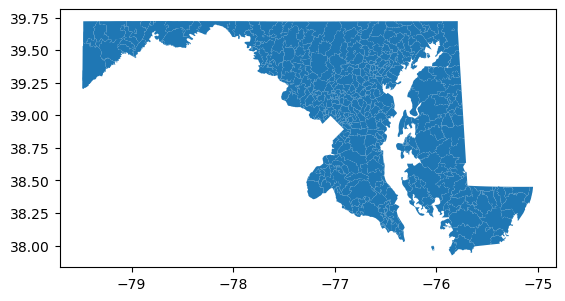

In [ ]:
# The original TIGER file contained all zipcodes for the whole US. The limit for Maryland zip codes were taken from
# the Zillow data to make sure they lined up more easily. I'm sure there is a way to have both boolean functions
# take place on the same row, but I'm not sure how. The GeoDataFrame geometry is set here rather than it needing to be later. 
gdb["Zipcode"].astype("int32").dtypes
gdb = gdb[gdb["Zipcode"] >= 20601]
gdb = gdb[gdb["Zipcode"] <= 21921]
gdb = gdb.set_geometry("Geometry")
gdb.plot()

In [ ]:
# This is just to check that the Zillow csv was imported correctly.
csvdf.head()

,RegionID,RegionName,State,City,CountyName,26-Feb
0,66705,20906,MD,Silver Spring,Montgomery County,441114
1,66843,21234,MD,Parkville,Baltimore County,298643
2,67010,21740,MD,Hagerstown,Washington County,286129
3,66683,20878,MD,Gaithersburg,Montgomery County,691253
4,66679,20874,MD,Germantown,Montgomery County,414290


In [ ]:
# In order to make the merge easier, new columns are created for the zip codes and housing prices within
# the csv dataframe.
csvdf["Housing_Prices"] = csvdf["26-Feb"]
csvdf["Zipcode"] = csvdf["RegionName"]

In [ ]:
# Now that the zipcode column exists, it is written over so that the data within is contained as an integer
# rather than as a string. This should allow it to work with the other dataframe. 
csvdf["Zipcode"] = csvdf["Zipcode"].astype("int")

In [ ]:
# Both dataframes are sorted by zipcode so they line up. I am unsure if this step is really required now that I
# have both zip code values properly stored as integers, but I'm not willing to mess with it. 
gdb.sort_values(by = ["Zipcode"])

,Geometry,Zipcode
10954,"POLYGON ((-76.99897 38.65535, -76.99872 38.655...",20601
10930,"POLYGON ((-76.93792 38.5971, -76.93751 38.5988...",20602
10966,"POLYGON ((-77.0473 38.61711, -77.04726 38.6171...",20603
22648,"POLYGON ((-76.75587 38.2583, -76.75529 38.2586...",20606
10944,"POLYGON ((-77.08052 38.68925, -77.0804 38.6892...",20607
...,...,...
23221,"POLYGON ((-76.1346 39.68068, -76.13458 39.6807...",21917
13001,"POLYGON ((-76.23328 39.72137, -76.22418 39.721...",21918
9969,"POLYGON ((-76.04288 39.37849, -76.03982 39.388...",21919
9956,"POLYGON ((-75.8506 39.65358, -75.84925 39.6538...",21920


In [ ]:
# Sorting has to be done in seperate code chunks for both dataframes, otherwise it only does it to one. 
csvdf.sort_values(by = ["RegionName"])

,RegionID,RegionName,State,City,CountyName,26-Feb,Housing_Prices,Zipcode
87,66494,20601,MD,Waldorf,Charles County,434584,434584,20601
95,66495,20602,MD,Waldorf,Charles County,386620,386620,20602
69,66496,20603,MD,Waldorf,Charles County,478570,478570,20603
396,66498,20606,MD,Abell,Saint Marys County,438147,438147,20606
190,66499,20607,MD,Accokeek,Prince Georges County,547489,547489,20607
...,...,...,...,...,...,...,...,...
277,67107,21917,MD,Colora,Cecil County,397243,397243,21917
242,67108,21918,MD,Conowingo,Cecil County,386528,386528,21918
274,67109,21919,MD,Earleville,Cecil County,366743,366743,21919
398,67110,21920,MD,Elkton,Cecil County,261027,261027,21920


In [ ]:
# Both dataframes are then merged into a new one using Zipcode as the common column.
merged = gdb.merge(csvdf, left_on="Zipcode", right_on = "Zipcode", suffixes=("_left", "_right"))

In [ ]:
# This is just to check that the merged dataframe has been correctly merged. 
merged.head()

,Geometry,Zipcode,RegionID,RegionName,State,City,CountyName,26-Feb,Housing_Prices
0,"POLYGON ((-75.40667 38.4154, -75.40666 38.4154...",21874,67094,21874,MD,Willards,Wicomico County,282956,282956
1,"POLYGON ((-75.88381 39.36706, -75.88379 39.367...",21912,67102,21912,MD,Warwick,Cecil County,557201,557201
2,"POLYGON ((-77.3167 39.07197, -77.31522 39.0747...",20854,66668,20854,MD,Potomac,Montgomery County,1272060,1272060
3,"POLYGON ((-77.64088 39.41539, -77.64078 39.415...",21769,67028,21769,MD,Middletown,Frederick County,558919,558919
4,"POLYGON ((-76.5001 39.31328, -76.5 39.3135, -7...",21221,66831,21221,MD,Essex,Baltimore County,288015,288015


<Axes: >

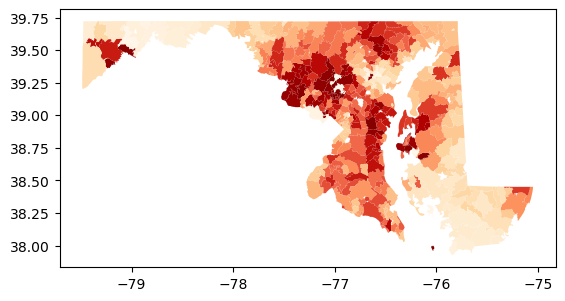

In [ ]:
# Now that merged has been created, it can be plotted. The column is assigned Housing_Prices to create a choropleth map. 
# The map color needs to be assigned otherwise it created a kaleidoscope of colors that even with a legend it could not be discerned.
merged.plot(column = "Housing_Prices", cmap='OrRd')

In [19]:
# Load warrants and make sure zip codes are stored as strings without decimals
warrants_df = pd.read_csv('md_eviction_warrants_through_sept2025.csv')

# Ensure zip codes are stored as strings
warrants_df['TenantZipCode'] = warrants_df['TenantZipCode'].astype('Int64').astype('string')
warrants_df['EventDate'] = pd.to_datetime(warrants_df['EventDate'])
warrants_df['EvictedDate'] = pd.to_datetime(warrants_df['EvictedDate'])
warrants_df['SourceDate'] = pd.to_datetime(warrants_df['SourceDate'])

len(warrants_df) # How many warrants are we working with?

607881

In [20]:
# Rather than geocoding 600K+ addresses, can we get only the unique ones?
geocode_input_df = exercise03.prep_warrants_for_geocoding(warrants_df)

607881 warrants input
Reduced to 205620 unique addresses


In [21]:
# The Census Geocoder API can only accept up to 10K rows at a time, so we have to break
# our dataframe into chunks

# Split into dataframes with less than 10K rows each
geocode_input_dfs = utils.chunk_dataframe(geocode_input_df, 9999)

# Save each dataframe as a CSV without a header
utils.save_dfs_to_csv(geocode_input_dfs, 'geocode_inputs', header=False)

split dataframe into 21 chunks


In [22]:
# Geocode addresses with the Census Geocoder (set test=True to process only one file)
census_geocode.geocode_csvs('geocode_inputs', 'geocode_outputs', test=True)

TEST MODE: Processing only one file.
Saved results to: geocode_outputs\geocoderesult_df_0.csv


In [23]:
# Recombine outputs from geocoder into a single dataframe
geocode_output_df = exercise03.combine_census_geocoded_csvs('geocode_outputs')
len(geocode_output_df)

9999

In [24]:
# Merge geocoded address back onto the inputs with separate fields for address, city, state, and zip
geocoded_df = geocode_input_df.merge(geocode_output_df, left_index=True, right_index=True)
len(geocoded_df)

9999

In [25]:
# Use address, city, state, and zip columns to join geocodes onto original warrant records
warrants_df = warrants_df.merge(geocoded_df, on=['TenantAddress','TenantCity','TenantState','TenantZipCode'])
len(warrants_df)

50754

In [26]:
warrants_df.head()

,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,Year,EvictionYear,unique_id,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side
0,0,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,8-N GLENSHANON COURT,Baltimore,MD,...,2025.0,NaN,4970,"1910 Fox Street APT 201, Adelphi, MD, 20783",Match,Exact,"1910 FOX ST, ADELPHI, MD, 20783","-76.975276009485,39.00849469185",657096978.0,L
1,1,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,1009 KENNEBEC STREET 1F,OXON HILL,MD,...,2025.0,2025.0,3640,"1056-L MISTY LYNN CIRCLE, Cockeysville, MD, 21030",No_Match,NaN,NaN,NaN,NaN,NaN
2,2,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1407-M CLEAR STREAM RD,Baltimore,MD,...,2025.0,NaN,4971,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215",Match,Exact,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215","-76.667147580336,39.337399996263",206406302.0,L
3,3,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1208-M WINDSAIL ROAD,Baltimore,MD,...,2025.0,NaN,2306,"2008 KINTORE CIRCLE #103, ODENTON, MD, 21113",Match,Exact,"2008 KINTORE CIR, ODENTON, MD, 21113","-76.7136333616,39.099213391212",636754538.0,R
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,2025.0,2025.0,3638,"1035-G MISTY LYNN CIRCLE, Cockeysville, MD, 21030",Match,Non_Exact,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R


In [27]:
# Convert warrants into a geodataframe with points
warrants_gdf = utils.lonlat_str_to_geodataframe(warrants_df, 'match_lon_lat')

In [28]:
# What proportion of records have points?
len(warrants_gdf[warrants_gdf.lon.notnull()]) / len(warrants_gdf)

0.9524766520865351

In [29]:
# What proportion of records have exact geocode matches?
len(warrants_gdf[warrants_gdf.match_type == 'Exact']) / len(warrants_gdf)

0.5736690704180951

Parquet is a file format for tabular data that efficiently stores data of many types, including a 'geoparquet' variant that stores geometries like points, lines, and polygons. You can easily save a dataframe or geodataframe to parquet with the `.to_parquet` method. The resulting file will be much smaller and load faster than more convetional formats, such as CSV or shapefile. The downside is that you won't be able to open it with Excel, ArcGIS, or other conventional desktop software.

`pip install pyarrow`

In [30]:
warrants_gdf.to_parquet('md_eviction_warrants_through_sept2025.geoparquet')

You can load a parquet file back to a dataframe with `pd.read_parquet('filename')` or a geoparquet back to a geodataframe with `gpd.read_parquet('filename')`

In [31]:
gdf = gpd.read_parquet('md_eviction_warrants_through_sept2025.geoparquet')

In [32]:
gdf.columns.tolist()

['Unnamed: 0',
 'ID',
 'EventDate',
 'EventType',
 'EventComment',
 'County',
 'Location',
 'TenantAddress',
 'TenantCity',
 'TenantState',
 'TenantZipCode',
 'CaseType',
 'CaseNumber',
 'EvictedDate',
 'Source',
 'SourceDate',
 'Year',
 'EvictionYear',
 'unique_id',
 'input_address',
 'match_status',
 'match_type',
 'match_address',
 'match_lon_lat',
 'match_tiger_line_id',
 'match_tiger_line_side',
 'lon',
 'lat',
 'geometry']

<Axes: >

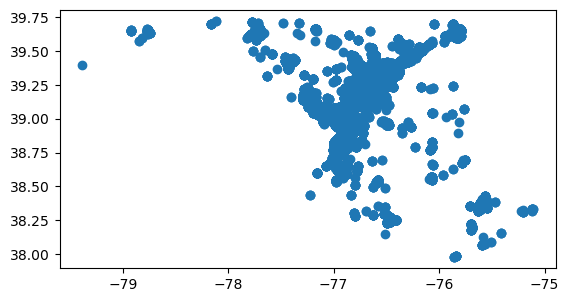

In [33]:
gdf.plot()

<Axes: >

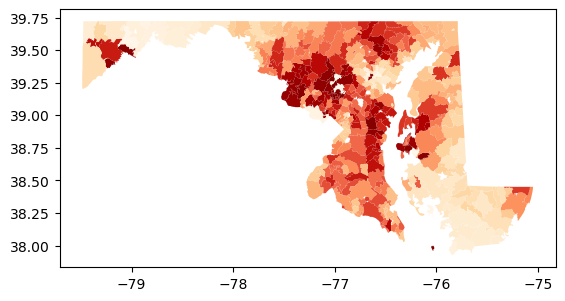

In [ ]:
# This is redone here at the end to make comparisons of the two maps easier.
merged.plot(column = "Housing_Prices", cmap='OrRd')